In [ ]:
import pandas as pd
import numpy as np

#The first dataset is mostly clean other than the date values being hard to read so our goal was to make it simpler

#Here we read in the dataset into the code so we can start the cleaning
fmap_df = pd.read_excel('FMAP.xlsx')
#Here we created a new column called date so the year and month are combined as one value with the first day value as included so its easier to read
#As a note we used Google Gemini to find the exact syntax for converting and formatting the date columns into the datetime string
fmap_df['Date'] = pd.to_datetime(fmap_df['Year'].astype(str) + '-' + fmap_df['Month'].astype(str) + '-01')
#Here we exported the final version of the dataset as a csv
fmap_df.to_csv('Cleaned_FMAP.csv', index=False)

#The second dataset is also a mostly clean dataset which only need suttle changes like converting the date values from strings to actual dates and cleaning the rows with empty date's

#Here we read in the dataset into the code to start the cleaning
national_df = pd.read_csv('NationalTotalAndSubcategory.csv')
#Here we converted the date values to datetime types so it is easier for us to process and do data analysis
national_df['Date'] = pd.to_datetime(national_df['Date'])
#Here we dropped all the rows with empty dates since they would stop us from properly doing analysis
national_df = national_df.dropna(subset=['Date'])
#Lastly we exported our new dataset as a csv
national_df.to_csv('Cleaned_National.csv', index=False)

#The third dataset was a bit more challenging since its format was unusual but we skipped over the weird rows and dropped all the empty values in the dataset as well as got past a formatting issue for the years.

#Here we read in the dataset and skipped the first 7 rows since they had random lines and information that isnt relevant
household_df = pd.read_excel('h02ar.xlsx', skiprows=7)
#Here we renamed the first two columns to year and households_thousand since even though they are named this in the file, python cannot read it correctly since the formatting is off and it needs to be manually inserted as the name
household_df.rename(columns={'Unnamed: 0': 'Year', 'Unnamed: 1': 'Number(thousands)'}, inplace=True)
#Here we dropped all the empty rows in the year column
household_df = household_df.dropna(subset=['Year'])
#Here we extracted the first 4 digits of the years so any other random numbers in front of the years would not be included and mess up the data.
#As a note we used Google Gemini to find the exact syntax for extracting a specific number of digits from a float.
household_df['Year'] = household_df['Year'].astype(str).str.extract(r'(\d{4})').astype(float)
#Here we converted our year values to integers so it is easier to do data analysis
household_df['Year'] = household_df['Year'].astype(int)
#Here we got rid of all the empty spaces in the headers for the columns since they took up extra space and made it complicated to analyze
household_df.columns = household_df.columns.str.replace('\n', ' ')
#Lastly we exported our new dataset as a csv
household_df.to_csv('Cleaned_Income.csv', index=False)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

fmap_df = pd.read_csv('Cleaned_FMAP.csv')
national_df = pd.read_csv('Cleaned_National.csv')
household_df = pd.read_csv('Cleaned_Income.csv')

#Convert dates just in case
national_df['Date'] = pd.to_datetime(national_df['Date'])
fmap_df['Date'] = pd.to_datetime(fmap_df['Date'])

# Set a clean style for all plots
sns.set_theme(style = "whitegrid", font_scale =1.1)

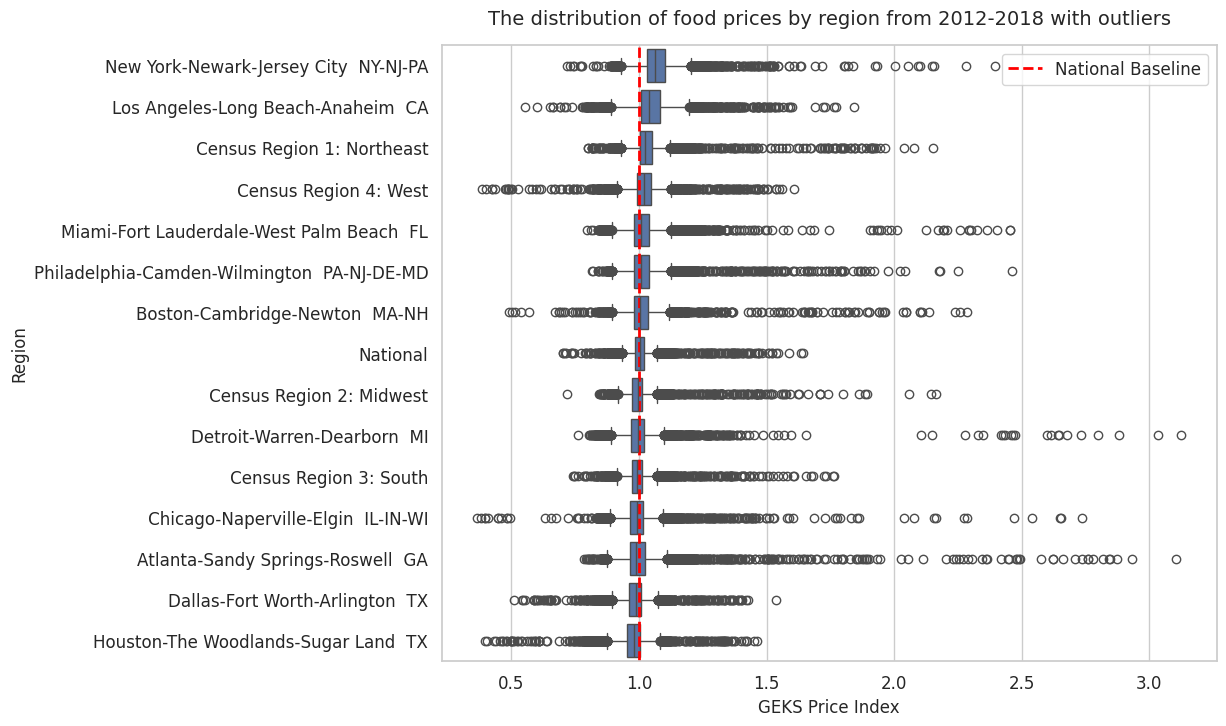

In [ ]:
#Here we plotted the boxplot using the FMAP data
plt.figure(figsize=(10, 8))
#We used AI for the syntax of the grouping of each data input
order = fmap_df.groupby('Metroregion_name')['Price_index_GEKS'].median().sort_values(ascending=False).index
sns.boxplot(x='Price_index_GEKS', y='Metroregion_name', data=fmap_df, order=order)
plt.title("The distribution of food prices by region from 2012-2018 with outliers", fontsize=14, pad=15)
plt.xlabel("GEKS Price Index", fontsize=12)
plt.ylabel("Region", fontsize=12)
#We used a vertical axis line in order to show the baseline for national metrics and its comparison to our data
plt.axvline(1.0, color='red', linestyle='dashed', linewidth=2, label='National Baseline')
plt.legend()
plt.savefig("graph1_withoutliers.png")

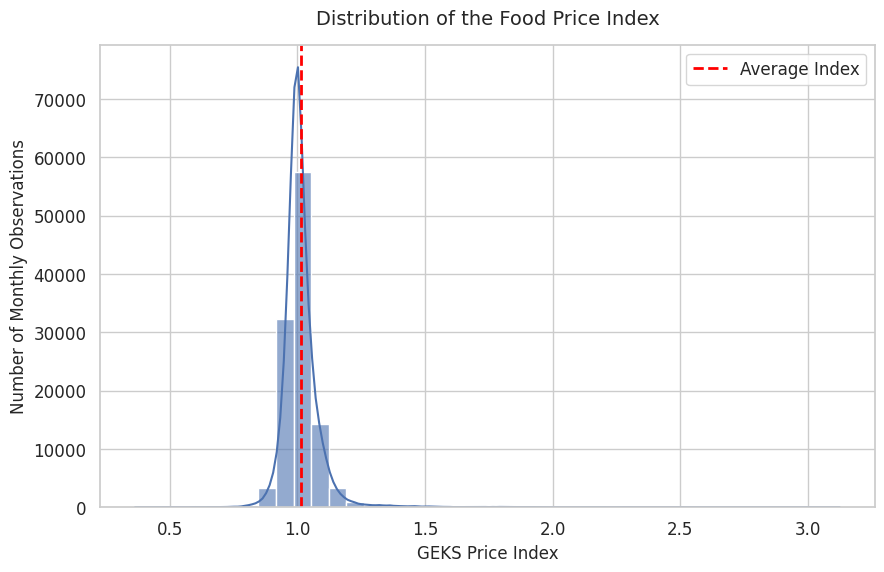

In [ ]:
#Here we plotted the distribution of food prices on a histogram based on monthly observations
plt.figure(figsize=(10, 6))
#We used AI to help us with the syntax of the histogram plotting
sns.histplot(fmap_df['Price_index_GEKS'], bins=40, kde=True, alpha=0.6)
plt.title("Distribution of the Food Price Index", fontsize=14, pad=15)
plt.xlabel("GEKS Price Index", fontsize=12)
plt.ylabel("Number of Monthly Observations", fontsize=12)
#We added a vertical axis line on the 1 price index since it represented the average in the country and helped us make observations
plt.axvline(fmap_df['Price_index_GEKS'].mean(), color='red', linestyle='dashed', linewidth=2, label='Average Index')
plt.legend()
plt.savefig("foodprice_distribution.png")